# Credit Card Approval Prediction using ML
### Jessica Campbell

I predict credit card application approvals based on anonymized data using logistic regression, KNN, and random forest models.

## About the Data

The credit card application data was obtained from the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/27/credit+approval), which was anonymized for confidentiality. This dataset contains 690 rows with mixed attributes and missing values.

The attributes are as follows:

`A1`:	a, b<br>
`A2`:	continuous<br>
`A3`:	continuous<br>
`A4`:	u, y, l, t<br>
`A5`:	g, p, gg<br>
`A6`:	c, d, cc, i, j, k, m, r, q, w, x, e, aa, ff<br>
`A7`:	v, h, bb, j, n, z, dd, ff, o<br>
`A8`:	continuous<br>
`A9`:	t, f<br>
`A10`: t, f<br>
`A11`: continuous<br>
`A12`: t, f<br>
`A13`: g, p, s<br>
`A14`: continuous<br>
`A15`: continuous<br>
`A16`: +,- (class)

## Step 1. Load Packages and Data
We'll start by loading the Python packages that we'll need along with the data.

In [7]:
# math and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# set seaborn style
sns.set_style('whitegrid')

# render Matplotlib figures
%matplotlib inline

In [26]:
# read in data while adding column names
header_names = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15','A16']
df = pd.read_csv('./data/crx.data',names=header_names)

## Step 2. Exploratory Data Analysis

Next, we'll perform Exploratory Data Analysis (EDA) to obtain a deeper understanding of the data. EDA is essential for identifying patterns, outliers, correlations, and potential data quality issues. Our EDA will focus on the following:

- Review basic summary statistics to understand the central tendency and scale of numerical variables
- Check for missing values, invalid entries, or duplicate samples
- Search for high-cardinality categorical features
- Visualize feature distributions to help identify skewed distributions or outliers
- Inspect the target variable's distribution to identify any class imbalance
- Visualize feature distributions by the target variable

### Step 2.1. Basic Summary Statistics
We'll use `panda`'s `df.head()` to see the first 5 rows of the data, `df.info()` to see a high-level summary of each column, and `df.describe()` to review a summary of basic statistics of the numeric variables.

In [77]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      690 non-null    object 
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     690 non-null    object 
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [30]:
df.describe()

,A3,A8,A11,A15
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


There are a total of 690 data samples with 2 float, 2 integer, and 12 object columns. Several object columns appear to contain float values (`A2`, `A3`, `A14`), so there may be invalid entries in these columns preventing these features from being entirely numeric. While three of the numeric columns have similar central tendencies and distribution widths, the `A15` column has a range of values that are several orders of magnitude larger than the rest. Feature scaling will therefore be needed to normalize the numerical columns to a consistent distribution, particularly for the logistic regression and KNN models.

### Step 2.2. Check for Missing Values, Invalid Entries, or Duplicates
Next we look for missing values, invalid entries, and duplicate samples. I'll start by verifying that there are no `null` entries using `panda`'s `df.isnull()` function.

In [32]:
# look for null entries
df.isnull().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

While there are no `null` entries, I like to search the object columns for placeholders such as `?` and `...` that might represent missing data.

In [41]:
# define placeholder entries to search for
placeholders = ['?', '.', 'na', 'n/a', 'none']

for col in df.select_dtypes(include='object'):
    mask = df[col].isin(placeholders)
    if mask.any():
        print(f"{col}:\n {df[mask][col]}\n\n")
    else:
        print(f"{col}: No placeholder entries.")

A1:
 248    ?
327    ?
346    ?
374    ?
453    ?
479    ?
489    ?
520    ?
598    ?
601    ?
641    ?
673    ?
Name: A1, dtype: object


A2:
 83     ?
86     ?
92     ?
97     ?
254    ?
286    ?
329    ?
445    ?
450    ?
500    ?
515    ?
608    ?
Name: A2, dtype: object


A4:
 206    ?
270    ?
330    ?
456    ?
592    ?
622    ?
Name: A4, dtype: object


A5:
 206    ?
270    ?
330    ?
456    ?
592    ?
622    ?
Name: A5, dtype: object


A6:
 206    ?
270    ?
330    ?
456    ?
479    ?
539    ?
592    ?
601    ?
622    ?
Name: A6, dtype: object


A7:
 206    ?
270    ?
330    ?
456    ?
479    ?
539    ?
592    ?
601    ?
622    ?
Name: A7, dtype: object


A9: No placeholder entries.
A10: No placeholder entries.
A12: No placeholder entries.
A13: No placeholder entries.
A14:
 71     ?
202    ?
206    ?
243    ?
270    ?
278    ?
330    ?
406    ?
445    ?
456    ?
592    ?
622    ?
626    ?
Name: A14, dtype: object


A16: No placeholder entries.


It looks like there are a number of missing entries with the placeholder `?` so let's replace these with the more common convention of `NaN` using `panda`'s `df.replace()` and inspect their distribution.

In [45]:
df.replace('?',np.nan,inplace=True)

In [49]:
df.isna().sum()

A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

The missing entries account for less than 2% of the dataset, so I will simply remove the corresponding samples using `panda`'s `df.dropna()`. If removing these entries was not an ideal solution, I could imputate them with the last valid entry using `panda`s `df.ffill()`.

In [63]:
df = df.dropna()

Let's verify that the rows with missing entries were successfully removed.

In [69]:
df.isna().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

With the missing entries removed, I will now look for duplicate samples using `panda`'s `df.duplicated()`.

In [72]:
# look for duplicate entries
df.duplicated().sum()

0

There are no duplicate entries. Now that there are no `?` placeholders for missing entries, I will try converting the three object columns `A2`, `A3`, and `A14` to floats.

In [81]:
df['A2'] = df.A2.astype(float)
df['A3'] = df.A3.astype(float)
df['A14'] = df.A14.astype(float)

I will now convert the two integer features A11 and A15 to floats.

In [85]:
df['A11'] = df.A11.astype(float)
df['A15'] = df.A15.astype(float)

Having converted three object to numeric features, I will review the summary statistics of the numeric features one final time.

In [89]:
df.describe()

,A2,A3,A8,A11,A14,A15
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,31.503813,4.829533,2.244296,2.502297,180.359877,1013.761103
std,11.838267,5.027077,3.371120,4.968497,168.296811,5253.278504
min,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.580000,1.040000,0.165000,0.000000,73.000000,0.000000
50%,28.420000,2.835000,1.000000,0.000000,160.000000,5.000000
75%,38.250000,7.500000,2.625000,3.000000,272.000000,400.000000
max,76.750000,28.000000,28.500000,67.000000,2000.000000,100000.000000


While `A2` and `A3` appear similar in nature to the other numeric features, the values in `A14` are orders of magnitude larger than the rest, just like we saw with `A15`. This reinforces the need for feature scaling.

### Step 2.3. Search for High-Cardinality Categorical Features
Next, I'll search for categorical features with high cardinality using `panda`'s `df.select_dtypes()`.

In [103]:
print("Number of unique labels per categorical feature:\n")
for col in df.select_dtypes(include='object'):
    print(f"{col}: {df[col].nunique()}")

Number of unique labels per categorical feature:

A1: 2
A4: 3
A5: 3
A6: 14
A7: 9
A9: 2
A10: 2
A12: 2
A13: 3
A16: 2


The categorical feature with the highest cardinality has a number of unique labels that corresponds to only 2% of the number of data samples. Since this is quite low, none of the categorical features are considered high cardinality.

### Step 2.4. Feature Distributions

#### Step 2.4.1. Visualize Feature Distributions
Now I will visualize the distribution of features, which is a simple yet effective way to identify data quality issues such as skewed distributions and outliers.

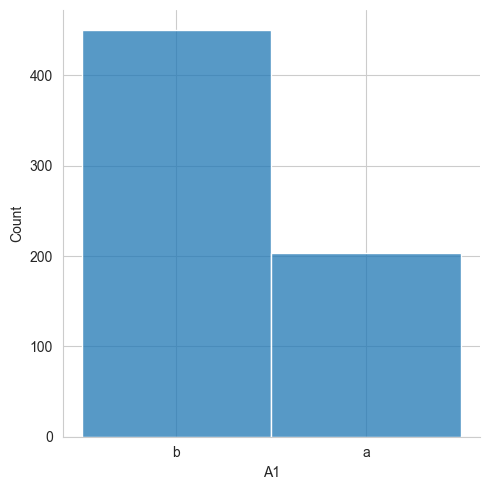

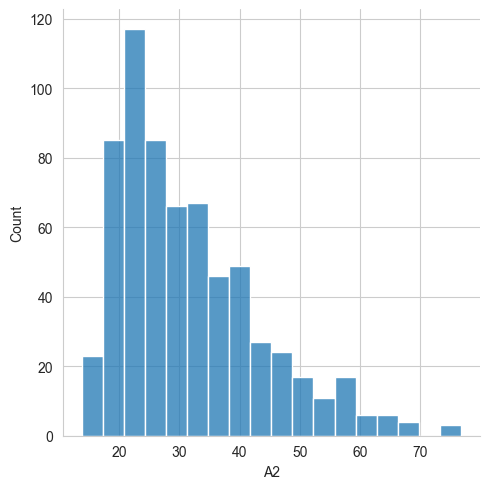

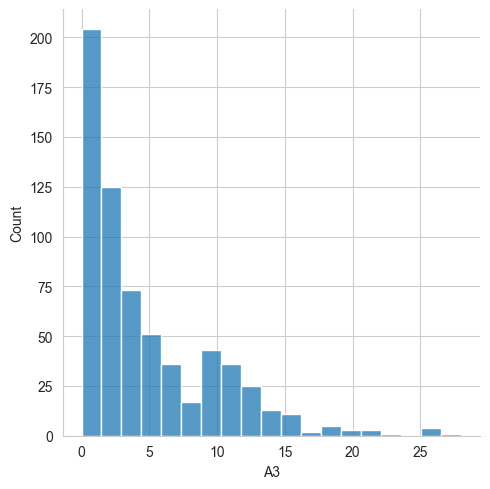

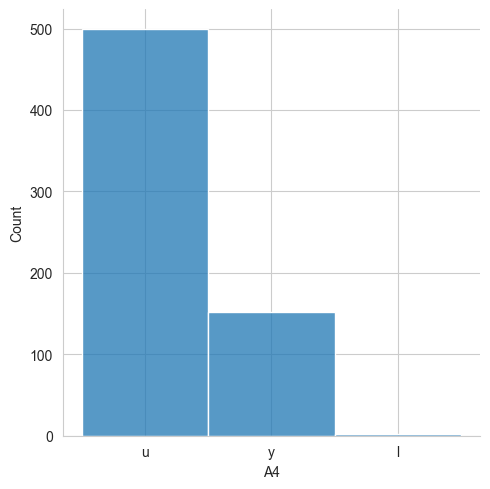

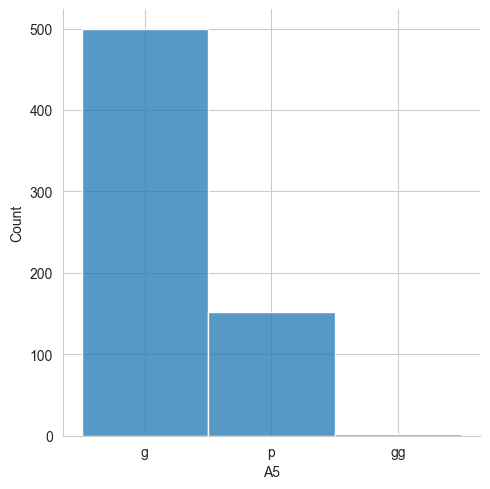

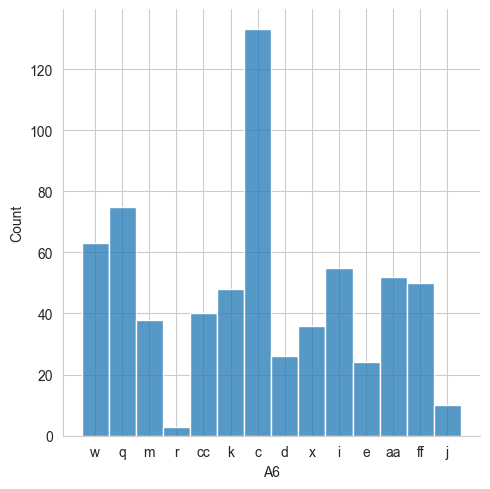

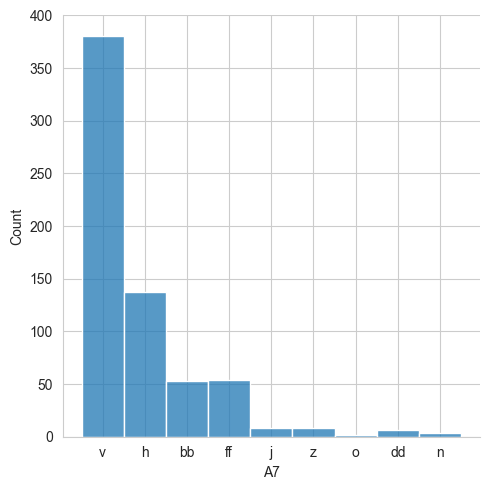

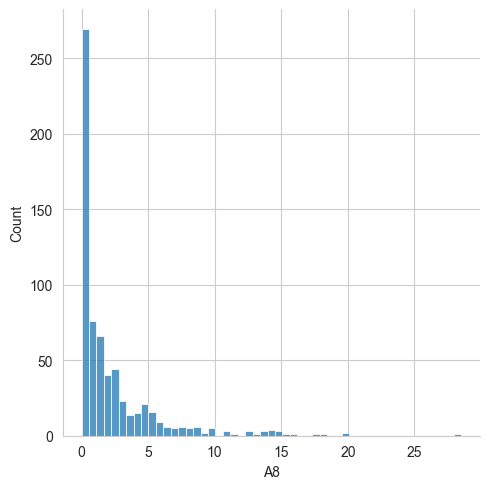

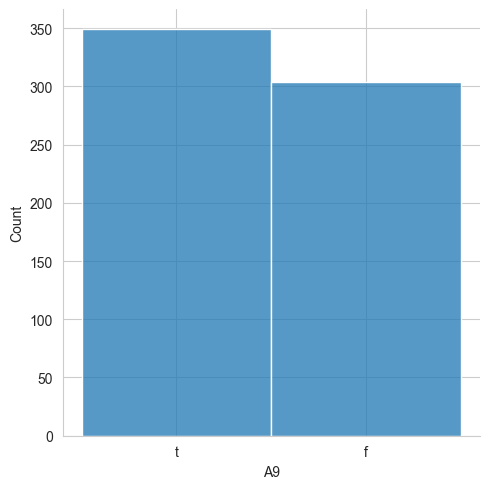

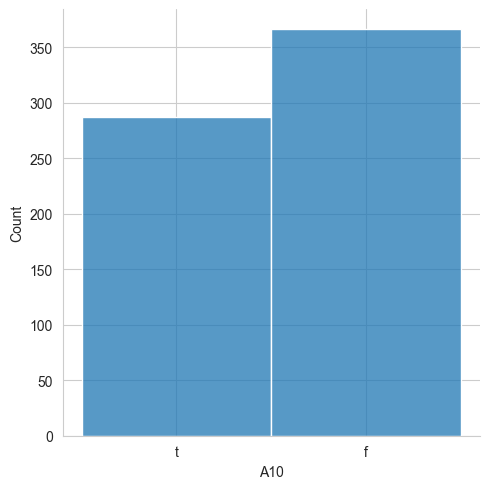

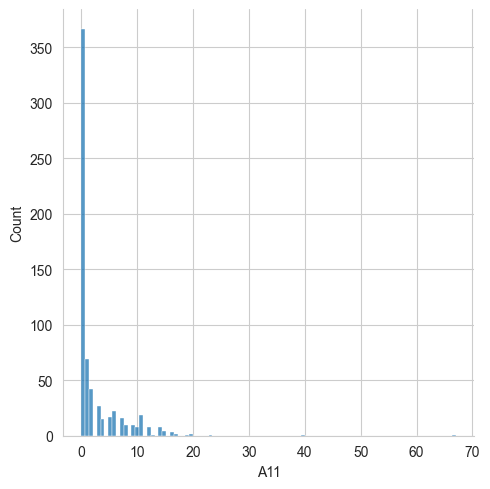

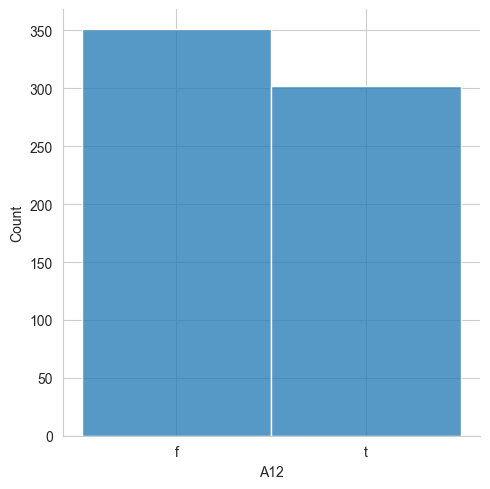

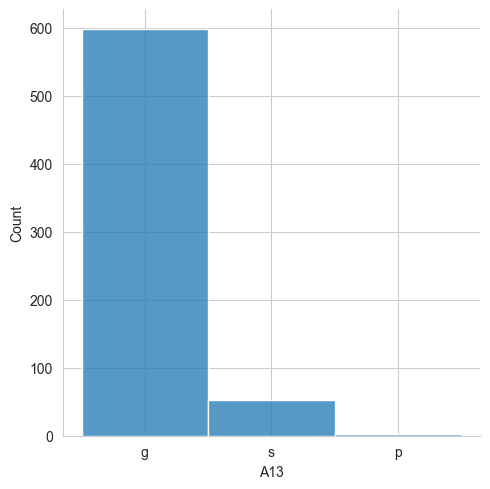

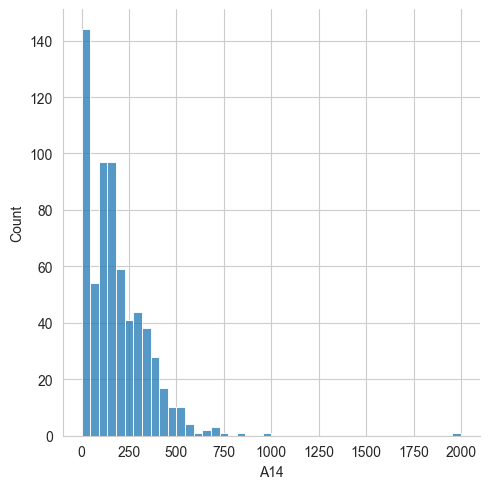

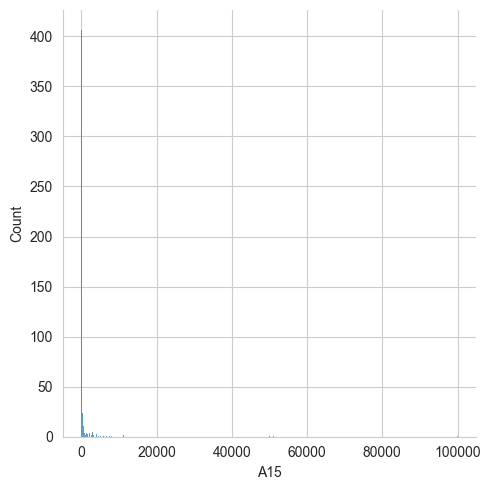

In [114]:
# plot feature distributions
for col in df.drop(columns=['A16']).columns:
    sns.displot(data=df,x=col)

This reveals that a number of features are quite heavy-tailed and have outliers that will need to be addressed. While random forests are generally robust against outliers, logistic regression and KNN models are sensitive to outliers as they use the magnitude of and distance between data points.

#### Step 2.4.2. Removing Feature Outliers

I will now search for and remove feature outliers. There are several ways to identify outliers, many of which rely on an assumption about the underlying distribution of the data. Given the heavy-tailed distributions seen here, I will use the standard approach of identifying outliers as those that are beyond 3 standard deviations from the mean ($\mu + 3\sigma$). The concept of 'outliers' does not apply to categorical features because there is no distance metric that applies to them, so this only applies to the numeric features. I will start by reviewing the feature distributions for only the numeric columns and add a vertical line representing the cutoff point for removing outliers. The feature A15 has an unusually heavy tail, so I will use one standard deviation in this case ($\mu + 1\sigma$).

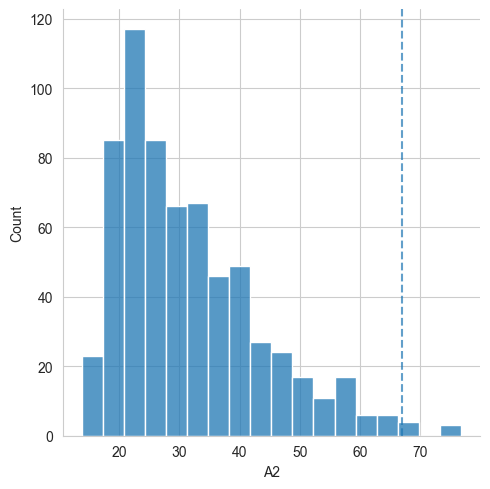

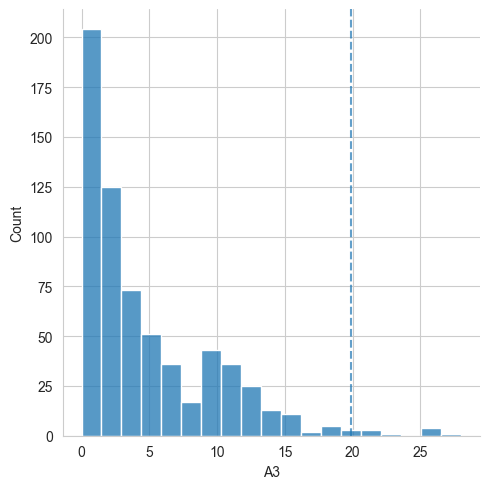

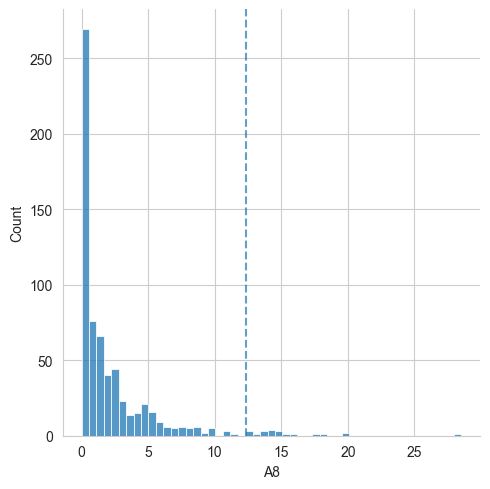

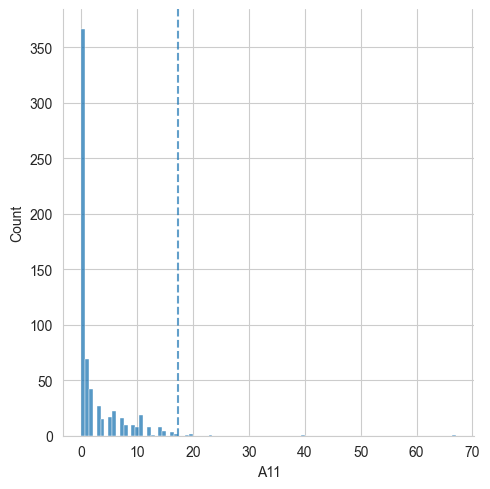

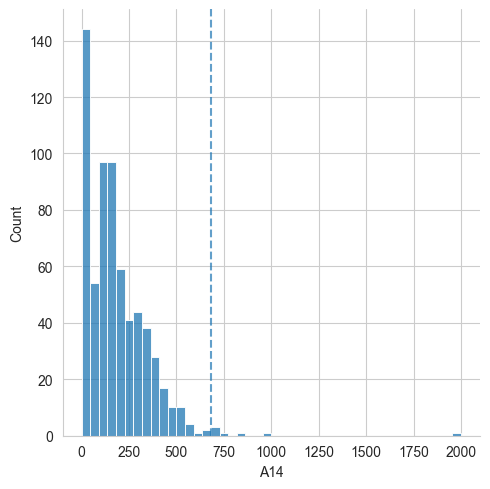

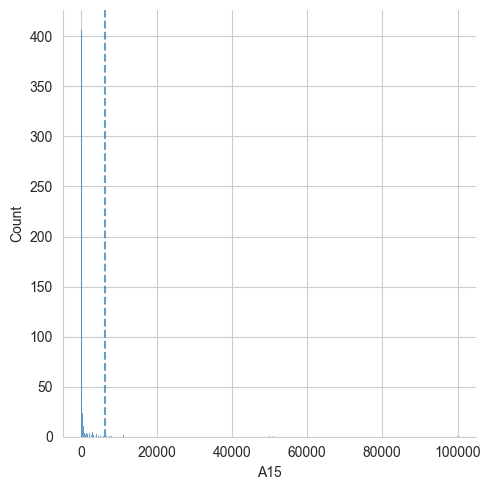

In [130]:
# plot feature distributions for numeric columns
# mark 3 standard deviations from the mean as a vertical line
for col in df.select_dtypes(include='float').columns:
    sns.displot(data=df,x=col,kde=False,color='tab:blue')
    # define sigma for vertical line
    if col=='A15':
        sigma=1
    else:
        sigma=3
    plt.axvline(np.mean(df[col])+sigma*np.std(df[col]),linestyle='dashed',alpha=0.7)

I will now define a function that I can use to clip data that is beyond N times the standard deviation from the mean, called `fclip()`. In light of the significant heavy-tailed distributions found here, we will perform two rounds of clipping where the mean and standard deviation are re-evaluated after the first round of clipping.

In [134]:
def fclip(df,columns):
    '''
    Iterates through columns in a dataframe and lips data beyond N multiples of the distribution's standard deviation.
    '''
    
    df_clipped = df.copy()
    
    for column in columns:
        
        # threshold for the number of standard deviations from the mean
        if column=='A15':
            sigma = 1
        else:
            sigma = 3
        
        # first round of clipping
        val = np.mean(df_clipped[column])+sigma*np.std(df_clipped[column])
        df_clipped.query('{}<@val'.format(column),inplace=True)
        
        # second round of clipping
        val = np.mean(df_clipped[column])+sigma*np.std(df_clipped[column])
        df_clipped.query('{}<@val'.format(column),inplace=True)
        
    return df_clipped

df = fclip(df,df.select_dtypes(include='float').columns)

I will now review the distributions of the numerical features to verify that the outliers were successfully clipped.

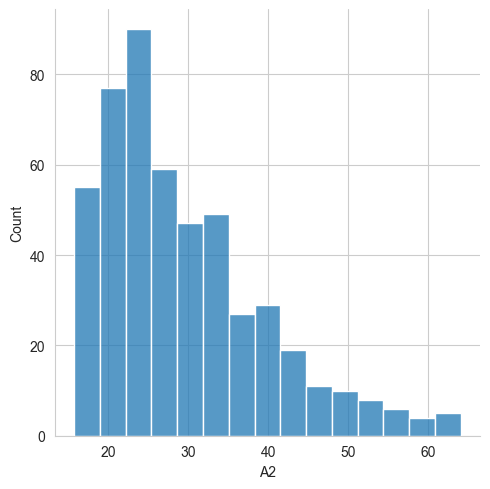

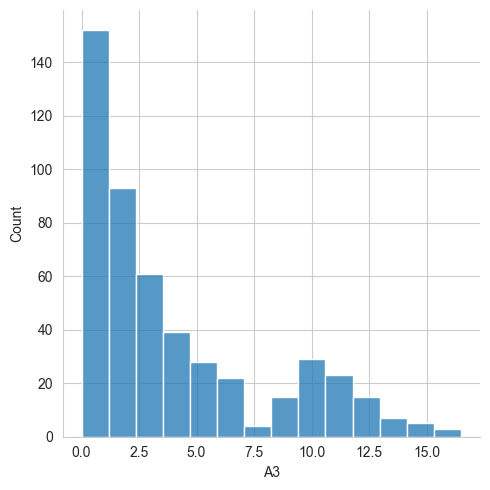

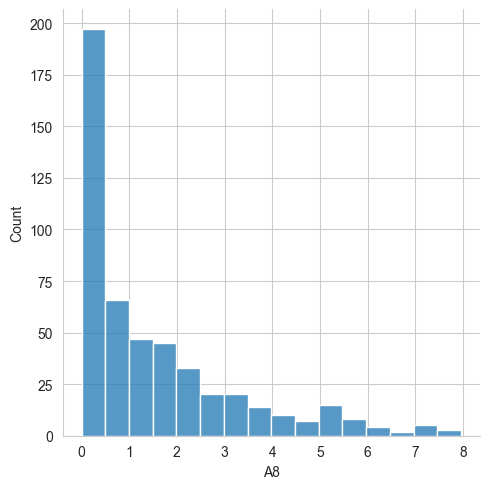

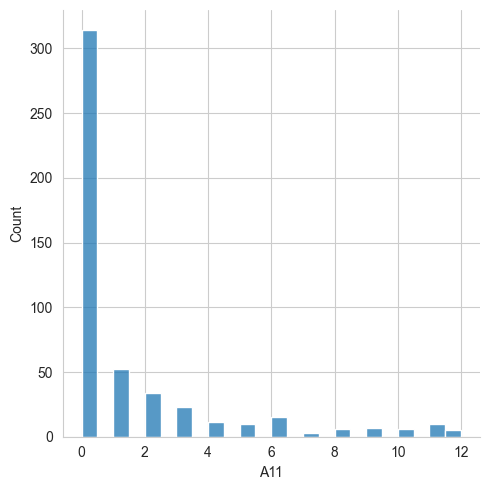

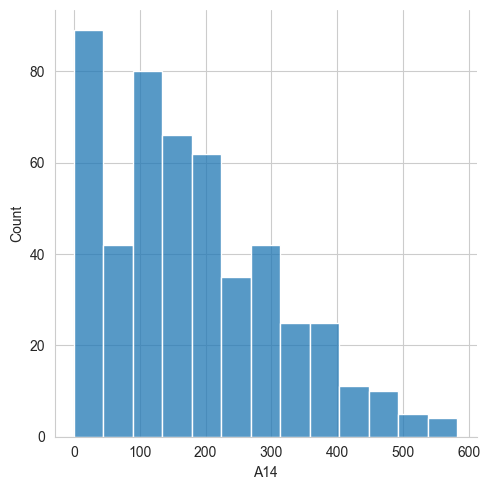

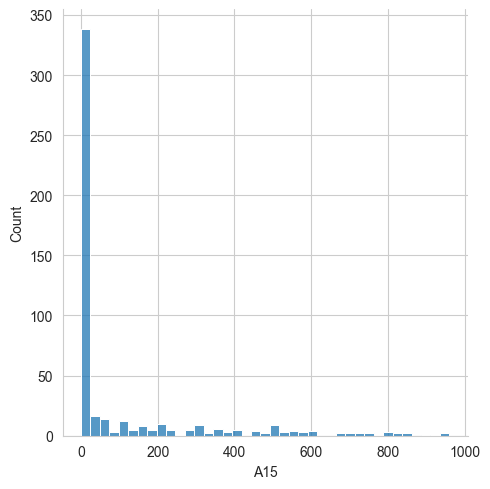

In [137]:
# plot feature distributions for numeric columns
for col in df.select_dtypes(include='float').columns:
    sns.displot(data=df,x=col,kde=False,color='tab:blue')

### Step 2.5. Visualize Target Variable Distribution
I will now take a look at the distribution of the target variable, `A16`.

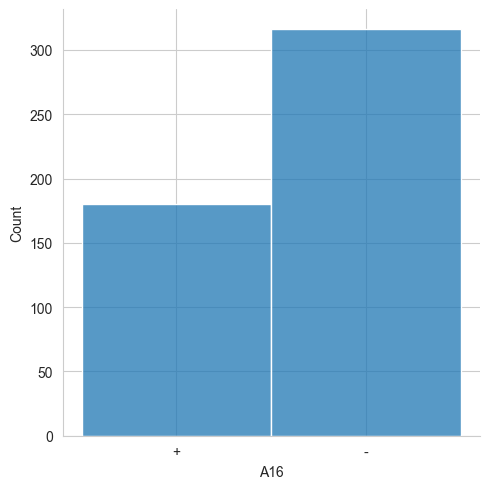

In [145]:
# plot distribution of target variable
sns.displot(data=df,x='A16',kde=False)

In [177]:
# inspect the underlying data of the target variable distribution
print("Class label value counts:")
print(df['A16'].value_counts())

print("\nClass label ratios:")
print(f"The ratio of positive to negative class labels +/-: {(df['A16']=='+').sum()/(df['A16']=='-').sum():.2f}")
print(f"The ratio of positive class labels to total samples: {(df['A16']=='+').sum()/len(df):.2f}")
print(f"The ratio of negative class labels to total samples: {(df['A16']=='-').sum()/len(df):.2f}")

Class label value counts:
A16
-    316
+    180
Name: count, dtype: int64

Class label ratios:
The ratio of positive to negative class labels +/-: 0.57
The ratio of positive class labels to total samples: 0.36
The ratio of negative class labels to total samples: 0.64


The class labels aren't significantly imbalanced, but there is an imbalance nevertheless. I will keep this in mind going forward, particularly while evaluating model performance as class imbalance can hinder a model's ability to learn and predict the minority class label. 

### Step 2.6. Visualize Feature Relationships
I will now visualize the relationships between numerical features and the target variable using `Seaborn`'s `sns.pairplot()` function, which shows scatterplots between different features on the off-diagonal elements and distributions of each feature along the diagonal elements. Using a colour scheme that differentiates between the two classes can be useful for identifying features that are linearly separable by class, which is an important underlying assumption of the logistic regression model, as well as clusters or regions in the feature space, which will be useful for the KNN model. I will restrict this visual to the numerical features as they will be more straightfoward to interpret.

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496 entries, 0 to 688
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      496 non-null    object 
 1   A2      496 non-null    float64
 2   A3      496 non-null    float64
 3   A4      496 non-null    object 
 4   A5      496 non-null    object 
 5   A6      496 non-null    object 
 6   A7      496 non-null    object 
 7   A8      496 non-null    float64
 8   A9      496 non-null    object 
 9   A10     496 non-null    object 
 10  A11     496 non-null    float64
 11  A12     496 non-null    object 
 12  A13     496 non-null    object 
 13  A14     496 non-null    float64
 14  A15     496 non-null    float64
 15  A16     496 non-null    object 
dtypes: float64(6), object(10)
memory usage: 65.9+ KB


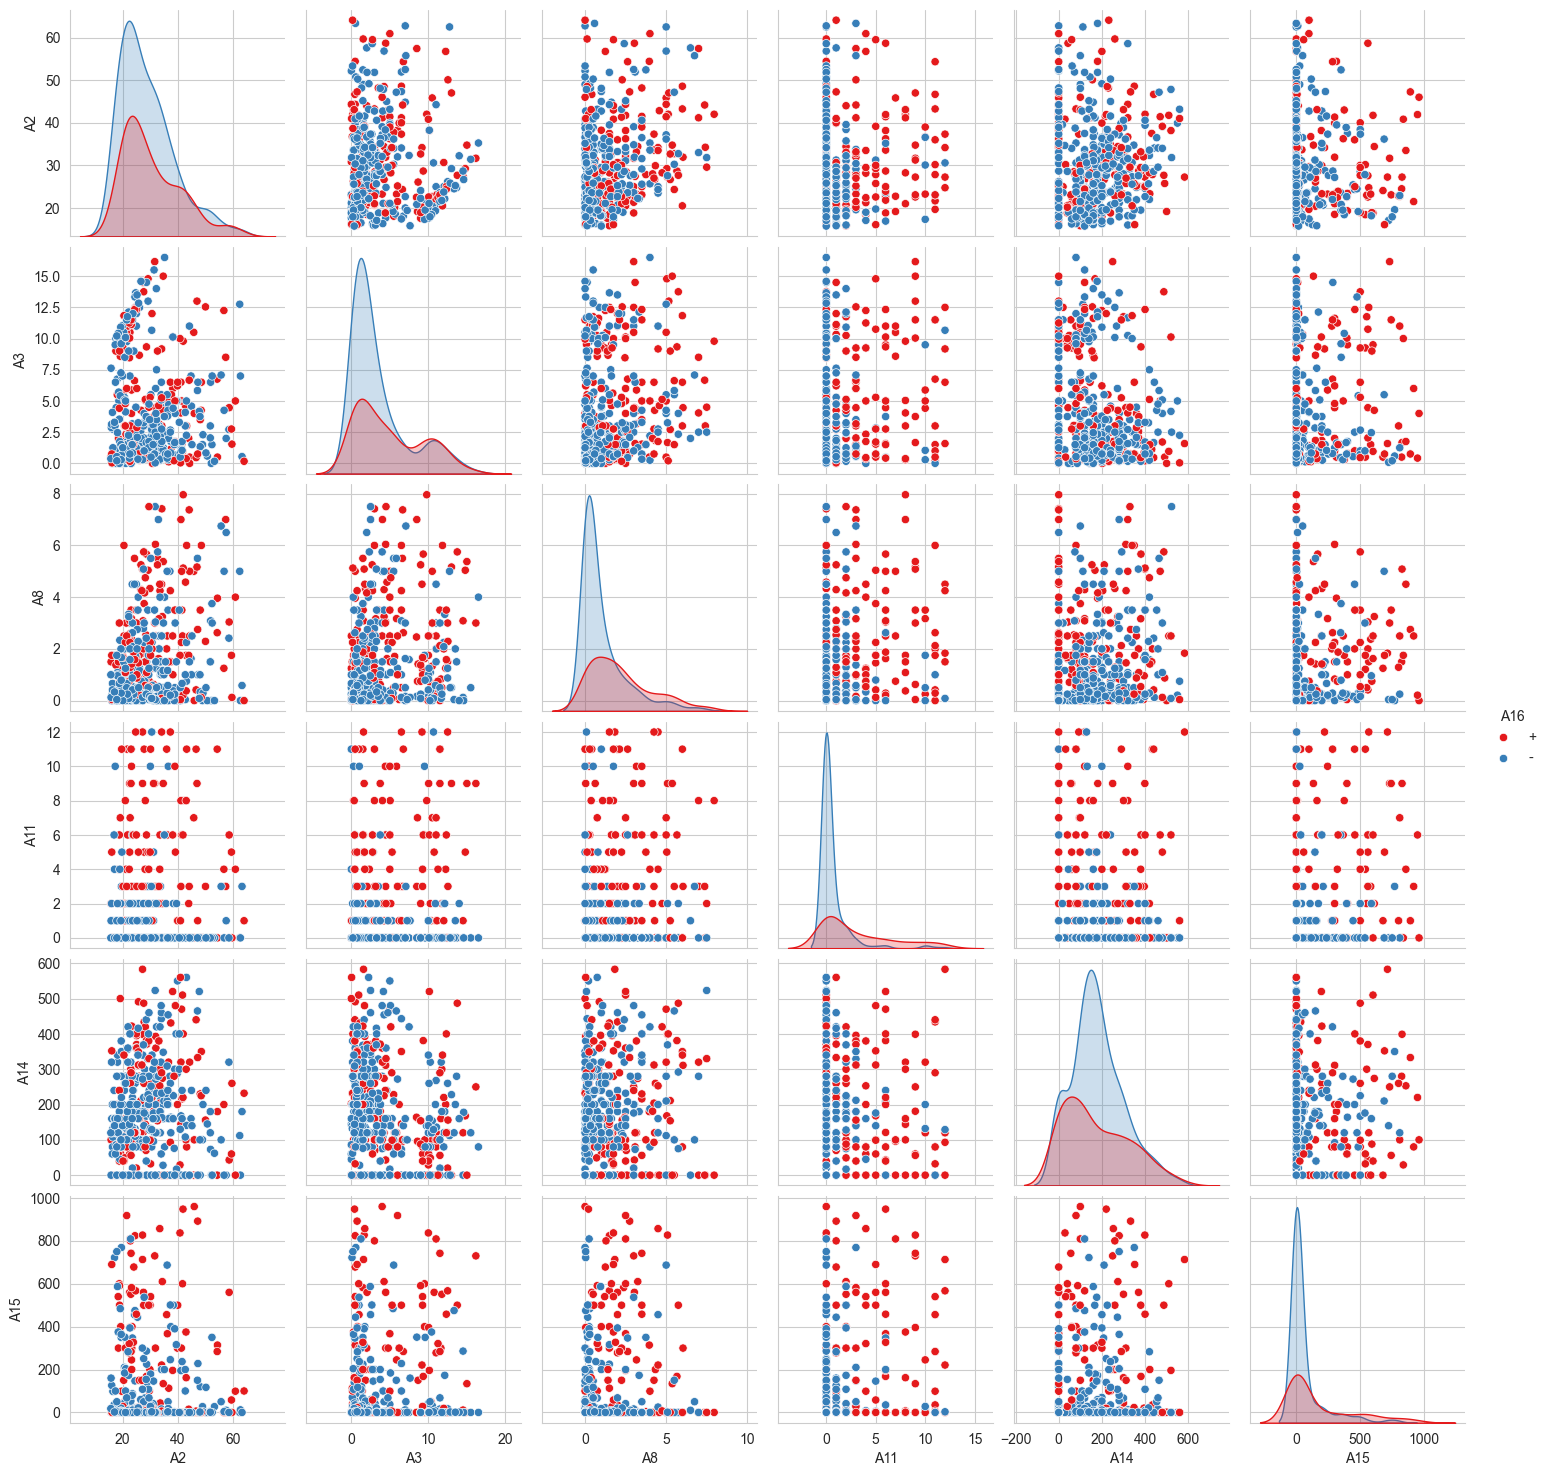

In [196]:
# produce pairplot
categorical_features = ['A1','A4','A5','A6','A7','A9','A10','A12','A13']
sns.pairplot(data=df.drop(columns=categorical_features),hue='A16',palette='Set1')

## Step 3: Feature Engineering
My exploratory analysis revealed the following areas where feature engineering will be needed to prepare the data for modelling:

- categorical features need to be encoded to numerical form
- continuous features need to be scaled to a consistent distribution central tendency and width

### Step 3.1. Feature Encoding

I'll start by encoding the categorical features so they can be used by the model. Since the data is anonymized, I don't know if the categorical features are ordinal (having a natural order) or nominal (not having a natural order). I don't think we can assume that (all of) the features are nominal, and doing so can significantly affect how the model interprets these features, particularly with the logistic regression and KNN models.

I'll take a safer bet and assume that they are nominal, for which I'll one-hot encoding. I'll do this using `panda`'s `pd.get_dummies()`, which converts the categorical features into binary features, and use `drop_first=True` to drop the redundant binary column to reduce multicolinearity. I'll generate the dummy variables separately so I can easily convert them from boolean type (True or False) to integer values (1 or 0).

In [198]:
# create dummy variables for categorical features and convert to integer datatype
df_dummies = pd.get_dummies(df[categorical_features],drop_first=True).astype(int)
encoded_categorical_features = df_dummies.columns.to_list()

# drop original categorical features from dataframe as they're now redundant
df = df.drop(columns=categorical_features)

# concatenate original dataframe with that containing the dummy variables
df = pd.concat([df, df_dummies], axis=1)

## Data Preprocessing



**Data Splitting**

We will split the dataframe into the features (denoted by `X`) and target variable (denoted by `y`):

In [17]:
X = credit_df.drop(['A16'],axis=1)
y = credit_df['A16']

**Variable Encoding**

We will assume that the classification variables are ordinal in that they contain a natural order that reflects the likelihood of whether their credit card application will be approved or not (e.g., credit score). To convert the categorical variables to numeric values, we will use scikit-learn's `OrdinalEncoder` function:

In [18]:
categorical_columns = ['A1','A4','A5','A6','A7','A9','A10','A12','A13']
X[categorical_columns]

,A1,A4,A5,A6,A7,A9,A10,A12,A13
0,b,u,g,w,v,t,t,f,g
1,a,u,g,q,h,t,t,f,g
2,a,u,g,q,h,t,f,f,g
3,b,u,g,w,v,t,t,t,g
4,b,u,g,w,v,t,f,f,s
...,...,...,...,...,...,...,...,...,...
685,b,y,p,e,h,f,f,f,g
686,a,u,g,c,v,f,t,t,g
687,a,y,p,ff,ff,f,t,t,g
688,b,u,g,aa,v,f,f,f,g


In [19]:
enc                    = OrdinalEncoder()
X[categorical_columns] = enc.fit_transform(X[categorical_columns])

Verify the results of the ordinal encoder by checking the header.

In [20]:
X.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1.0,30.83,0.000,1.0,0.0,12.0,7.0,1.25,1.0,1.0,1.0,0.0,0.0,202.0,0.0
1,0.0,58.67,4.460,1.0,0.0,10.0,3.0,3.04,1.0,1.0,6.0,0.0,0.0,43.0,560.0
2,0.0,24.50,0.500,1.0,0.0,10.0,3.0,1.50,1.0,0.0,0.0,0.0,0.0,280.0,824.0
3,1.0,27.83,1.540,1.0,0.0,12.0,7.0,3.75,1.0,1.0,5.0,1.0,0.0,100.0,3.0
4,1.0,20.17,5.625,1.0,0.0,12.0,7.0,1.71,1.0,0.0,0.0,0.0,2.0,120.0,0.0


Concatenate the encoded features and target variable data frames.

In [21]:
credit_df_new = pd.concat([X,y],axis=1)

## Training and Testing Data Sets

**Split the data into features and target variables.**

Let's separate the feature data (`X`) from the target variable (`y`) using standard nomenclature:

In [26]:
X = credit_df_clipped.drop('A16',axis=1)
y = credit_df_clipped['A16']

Verify the columns in `X` and `y` by inspecting their headers.

In [27]:
X.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1.0,30.83,0.000,1.0,0.0,12.0,7.0,1.25,1.0,1.0,1.0,0.0,0.0,202.0,0.0
1,0.0,58.67,4.460,1.0,0.0,10.0,3.0,3.04,1.0,1.0,6.0,0.0,0.0,43.0,560.0
2,0.0,24.50,0.500,1.0,0.0,10.0,3.0,1.50,1.0,0.0,0.0,0.0,0.0,280.0,824.0
3,1.0,27.83,1.540,1.0,0.0,12.0,7.0,3.75,1.0,1.0,5.0,1.0,0.0,100.0,3.0
4,1.0,20.17,5.625,1.0,0.0,12.0,7.0,1.71,1.0,0.0,0.0,0.0,2.0,120.0,0.0


In [28]:
y.head()

0    +
1    +
2    +
3    +
4    +
Name: A16, dtype: object

**Split the data into the training and testing sets.**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

**Standardization**

With the data being split into training and testing data sets, we will standardize the training set by removing the mean and normalizing the variance from each numerical feature such that the mean is zero and the variance is one. Similar to removing outliers, standardization only applies to numerical features so we will use `ColumnTransformer()`, which allows us to specify the numerical features of `X_train` that we want to be standardized.

In [30]:
ct = ColumnTransformer([('ctname', StandardScaler(), X.drop(categorical_columns,axis=1).columns)], remainder='passthrough')

In [31]:
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled  = ct.fit_transform(X_test)

Visualize the standardized data using histograms.

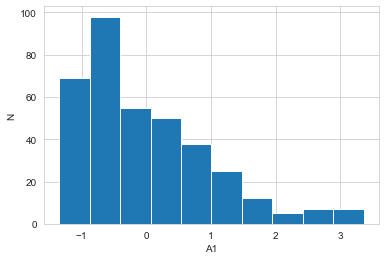

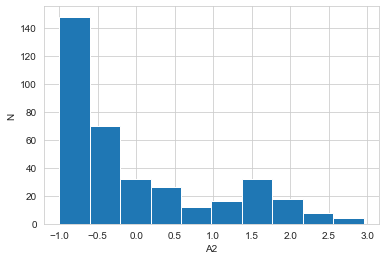

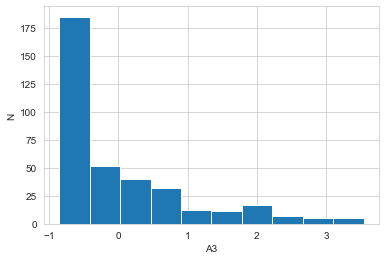

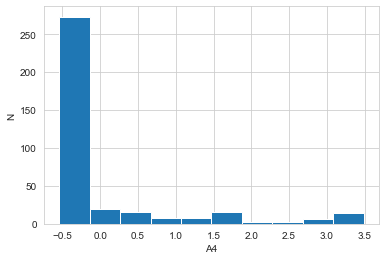

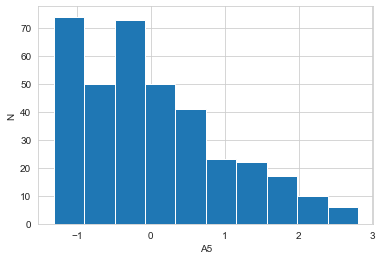

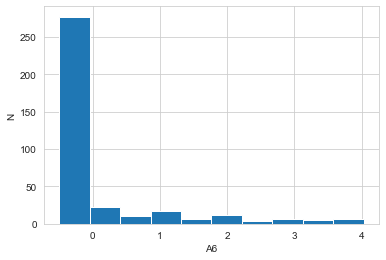

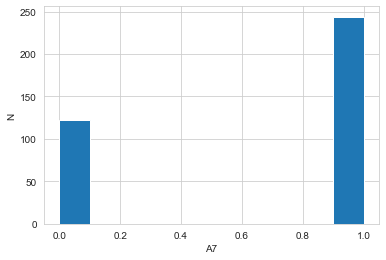

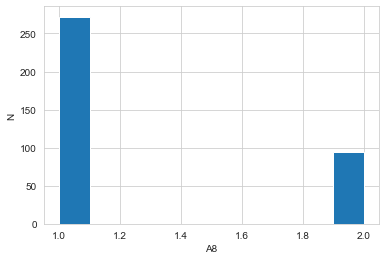

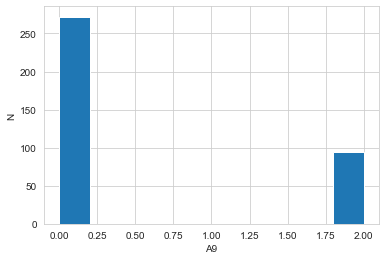

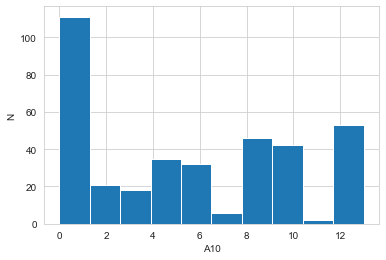

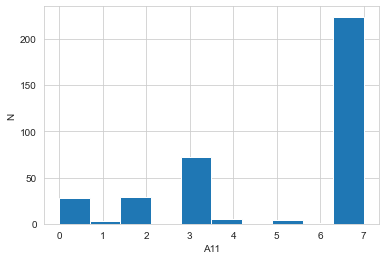

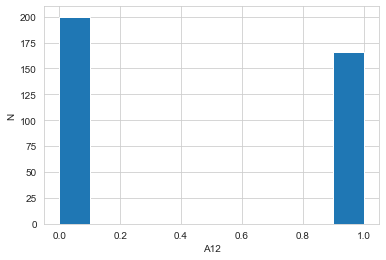

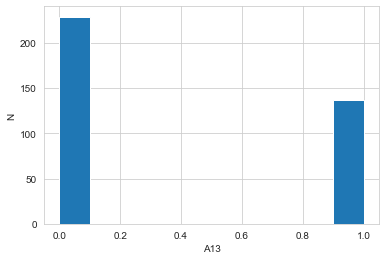

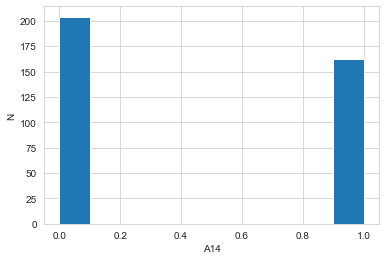

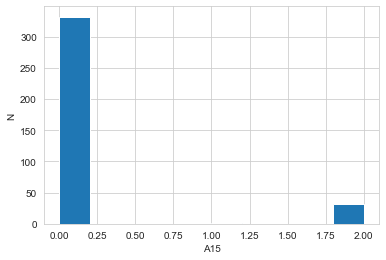

In [32]:
for i in np.arange(X_train_scaled.shape[1]):
    column = X.columns[i]
    fig = plt.figure()
    plt.hist(X_train_scaled[:,i])
    plt.xlabel(column)
    plt.ylabel('N')
    plt.show()
    plt.clf()
    plt.close()

## Logistic Regression Model

**Train the logistic regression model using the standardized training set.**

In [33]:
logm = LogisticRegression()
logm.fit(X_train_scaled,y_train)

LogisticRegression()

**Predict values of the logistic regression model using the testing set.**

In [34]:
y_predictions = logm.predict(X_test_scaled)

**Check the confusion matrix and classification report for the logistic regression model.**

In [35]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_predictions))
print('\nClassification report:')
print(classification_report(y_test,y_predictions))

Confusion matrix:
[[44  7]
 [15 92]]

Classification report:
              precision    recall  f1-score   support

           +       0.75      0.86      0.80        51
           -       0.93      0.86      0.89       107

    accuracy                           0.86       158
   macro avg       0.84      0.86      0.85       158
weighted avg       0.87      0.86      0.86       158



## KNN Model

**Train the KNN model using the standardized training set.**

In [36]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled,y_train)
#knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

**Predict values of the KNN model using the testing set.**

In [37]:
y_predict = knn.predict(X_test_scaled)

**Check the confusion matrix and classification report for the KNN model.**

In [38]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_predict))
print('\nClassification report:')
print(classification_report(y_test,y_predict))

Confusion matrix:
[[35 16]
 [18 89]]

Classification report:
              precision    recall  f1-score   support

           +       0.66      0.69      0.67        51
           -       0.85      0.83      0.84       107

    accuracy                           0.78       158
   macro avg       0.75      0.76      0.76       158
weighted avg       0.79      0.78      0.79       158



**Choosing a K Value**

We will use the elbow method to choose the value of K that optimizes our model. We will create a for loop that trains KNN models with a range of k values and analyze the error rate of our models.

In [39]:
error_rate = []

for k in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)
    #knn.fit(X_train,y_train)
    y_predict = knn.predict(X_test_scaled)
    error_rate.append(np.mean(y_predict!=y_test))

Plot the error rate vs. K for all KNN models:

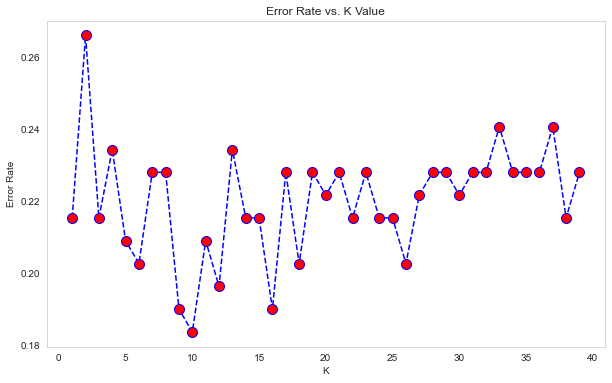

In [40]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,ls='--',color='blue',marker='o',markerfacecolor='red',markersize=10)
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.title('Error Rate vs. K Value')
plt.grid()

Looking at the plot above, we can see that the value of k=10 is a resonable value to choose that optimizes the error rate of the KNN model.

**Re-train the KNN model using the optimized K value.**

In [41]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled,y_train)
#knn.fit(X_train,y_train)
y_predict = knn.predict(X_test_scaled)

**Check the confusion matrix and classification report for the optimized KNN model.**

In [42]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_predict))
print('\nClassification report:')
print(classification_report(y_test,y_predict))

Confusion matrix:
[[30 21]
 [ 8 99]]

Classification report:
              precision    recall  f1-score   support

           +       0.79      0.59      0.67        51
           -       0.82      0.93      0.87       107

    accuracy                           0.82       158
   macro avg       0.81      0.76      0.77       158
weighted avg       0.81      0.82      0.81       158



## Random Forest Model

**Train the random forest model using the standardized training set.**

In [43]:
rf = RandomForestClassifier(n_estimators=1)
rf.fit(X_train_scaled,y_train)

RandomForestClassifier(n_estimators=1)

**Predict values using the testing data.**

In [44]:
y_predict = rf.predict(X_test_scaled)

**Check the confusion matrix and classification report for the random forest model.**

In [45]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_predict))
print('\nClassification report:')
print(classification_report(y_test,y_predict))

Confusion matrix:
[[43  8]
 [16 91]]

Classification report:
              precision    recall  f1-score   support

           +       0.73      0.84      0.78        51
           -       0.92      0.85      0.88       107

    accuracy                           0.85       158
   macro avg       0.82      0.85      0.83       158
weighted avg       0.86      0.85      0.85       158



**Choosing n_values.**

We will create a for loop that trains random forest models with a range of n_values and analyze the accuracy score of our models to find an optimal value.

In [46]:
n_values        = np.arange(1,100)
accuracy_scores = []

for n in n_values:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train_scaled,y_train)
    y_predictions_rf = rf.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test,y_predictions_rf))

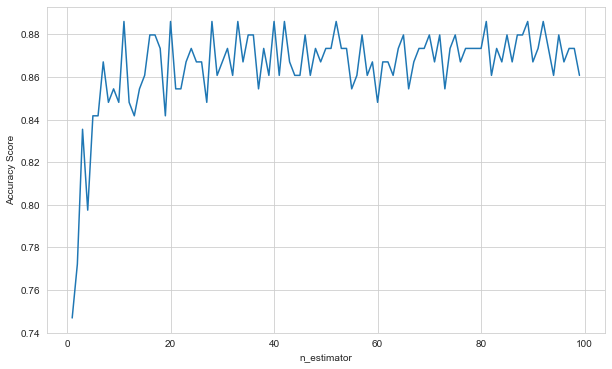

In [47]:
fig = plt.figure(figsize=(10,6))
plt.plot(n_values,accuracy_scores)
plt.xlabel('n_estimator')
plt.ylabel('Accuracy Score')
plt.show()

Looking at the plot above, we can see that the value of n_estimator=19 is a resonable value to choose that optimizes the accuracy score of the random forest model.

**Retrain with Optimized n_values**

We will re-train the random forest model with the optimal value of n_estimator that we found above using the same training data as before.

In [48]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train_scaled,y_train)
y_predict = rf.predict(X_test_scaled)

**Check confusion matrix and classification report for the optimized random forest model.**

In [49]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_predict))
print('\nClassification report:')
print(classification_report(y_test,y_predict))

Confusion matrix:
[[45  6]
 [13 94]]

Classification report:
              precision    recall  f1-score   support

           +       0.78      0.88      0.83        51
           -       0.94      0.88      0.91       107

    accuracy                           0.88       158
   macro avg       0.86      0.88      0.87       158
weighted avg       0.89      0.88      0.88       158



## Model Comparison

As we can see from comparing the three models below, the optimized random forest model out-performed the logistic regression model and the optimised KNN model.

| Model | Precision | Recall | f1-score
| --- | --- | --- | --- |
| Logistic regression | 0.87 | 0.86 | 0.86 |
| KNN | 0.81 | 0.82 | 0.81 |
| Random forest | 0.89 | 0.88 | 0.88 |